In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier

### DATA LOADING 

In [5]:
df = pd.read_excel("New_columns.xlsx")

### DATA UNDERSTANDING 

In [6]:
df.head()

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales,Sales_Category
0,TXN100002,2025-07-22,Customer,Swap,BSC,20555.75,32.61,VIP,America,203,38.98,Pass,Yes,929.0,12870.12,24666.900,0
1,TXN100003,2025-12-27,NaN,Staking,Solana,25571.60,16.49,Institutional,Europe,152,56.57,Pass,No,519.0,5099.70,30685.920,1
2,TXN100004,2025-07-27,Operational,DeFi,Polygon,40219.77,39.93,Retail,Europe,27,82.62,Review,Yes,2002.0,22341.17,48263.724,1
3,TXN100005,2025-08-27,Customer,saving,Polygon,44989.59,18.03,VIP,Europe,177,1.05,Pass,No,3205.0,31676.08,-5000.000,0
4,TXN100006,2025-12-16,Treasury,DeFi,Solana,24827.30,77.33,Institutional,Middle East,202,29.83,Review,No,3439.0,24182.19,29735.688,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              1995 non-null   object 
 1   Date                        1981 non-null   object 
 2   Wallet_Type                 1921 non-null   object 
 3   Tran_Type                   1974 non-null   object 
 4   Blockchain                  1982 non-null   object 
 5   Amount                      2000 non-null   float64
 6   Gas_Fee_USD                 2000 non-null   float64
 7   Customer_Type               1980 non-null   object 
 8   Region                      1973 non-null   object 
 9   Processing_Time_sec         2000 non-null   int64  
 10  Fraud_Risk_Score            2000 non-null   float64
 11  Compliance_Status           1971 non-null   object 
 12  Marketing_Campaign          1991 non-null   object 
 13  Number_of_Active_Customers  2000 

In [8]:
df.describe()

,Amount,Gas_Fee_USD,Processing_Time_sec,Fraud_Risk_Score,Number_of_Active_Customers,Daily_Revenue_USD,Sales,Sales_Category
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000
mean,24991.905660,59.419555,153.138500,48.761885,2553.147000,22377.354280,3.667250e+05,0.497000
std,14309.854047,35.038321,85.729091,28.871476,1418.111223,10376.427782,1.470709e+07,0.500116
min,-15000.000000,0.650000,5.000000,0.060000,51.000000,235.680000,-5.555570e+05,0.000000
25%,12216.972500,28.240000,80.000000,23.795000,1359.750000,14427.055000,1.457160e+04,0.000000
50%,24827.300000,59.020000,154.000000,47.930000,2549.500000,22388.270000,2.973569e+04,0.000000
75%,37309.065000,89.817500,225.250000,73.017500,3776.000000,30087.262500,4.477088e+04,1.000000
max,49979.940000,119.970000,300.000000,99.900000,6676.000000,50623.470000,6.576645e+08,1.000000


In [9]:
df.isnull().sum()

Transaction_ID                 5
Date                          19
Wallet_Type                   79
Tran_Type                     26
Blockchain                    18
Amount                         0
Gas_Fee_USD                    0
Customer_Type                 20
Region                        27
Processing_Time_sec            0
Fraud_Risk_Score               0
Compliance_Status             29
Marketing_Campaign             9
Number_of_Active_Customers     0
Daily_Revenue_USD              0
Sales                          0
Sales_Category                 0
dtype: int64

In [10]:
df.duplicated().sum()

0

### DATA CLEANING 

In [11]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

In [12]:
df[df.select_dtypes(include="number").columns] = (
    df.select_dtypes(include="number")
      .fillna(df.select_dtypes(include="number").median())
)

In [13]:
df[df.select_dtypes(include="object").columns] = (
    df.select_dtypes(include="object")
      .fillna("Unknown")
)

In [14]:
df = df.drop_duplicates()

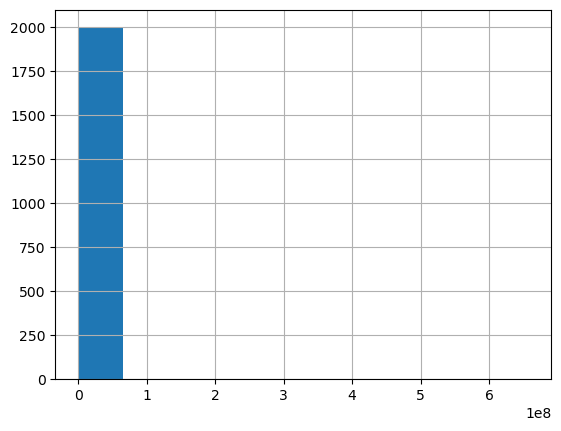

In [15]:
df["Sales"].hist()

plt.show()

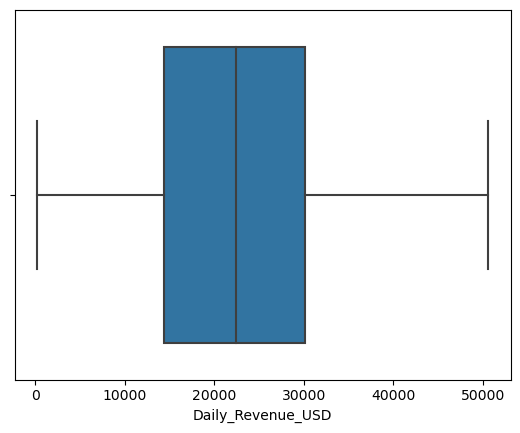

In [16]:
sns.boxplot(x=df["Daily_Revenue_USD"])

plt.show()

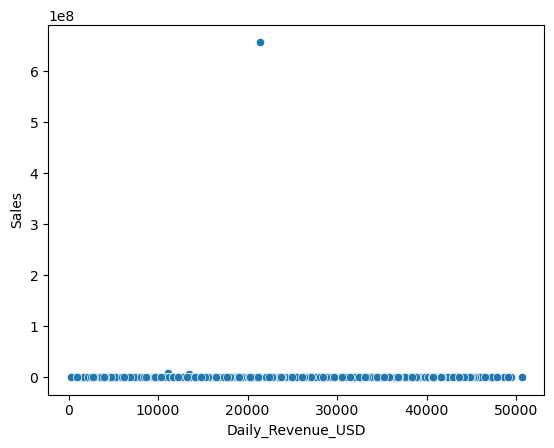

In [17]:
sns.scatterplot(
    x="Daily_Revenue_USD",
    y="Sales",
    data=df
)

plt.show()

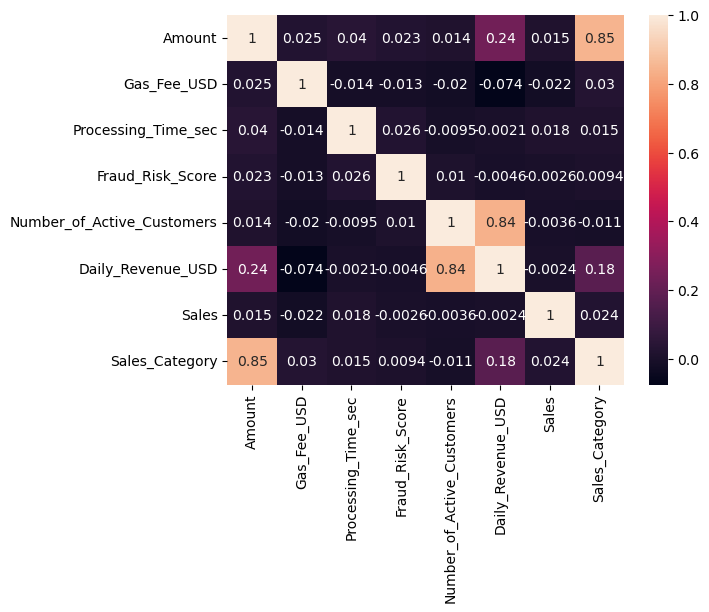

In [18]:
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True)

plt.show()

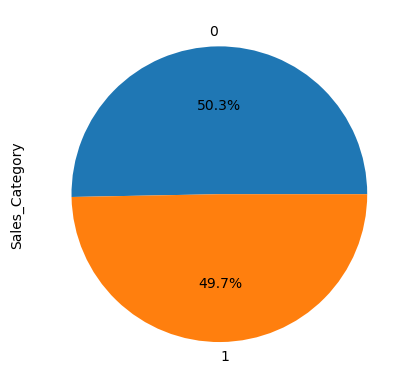

In [19]:
df["Sales_Category"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.show()

### APPLYING MODEL 

In [20]:
X = df[["Amount","Gas_Fee_USD","Daily_Revenue_USD"]]

y = df["Sales_Category"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [22]:
model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

In [23]:
model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [24]:
predictions = model.predict(X_test)

In [25]:
accuracy_score(y_test, predictions)

0.9875

In [26]:
cm = confusion_matrix(y_test, predictions)

pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

,Predicted 0,Predicted 1
Actual 0,198,4
Actual 1,1,197


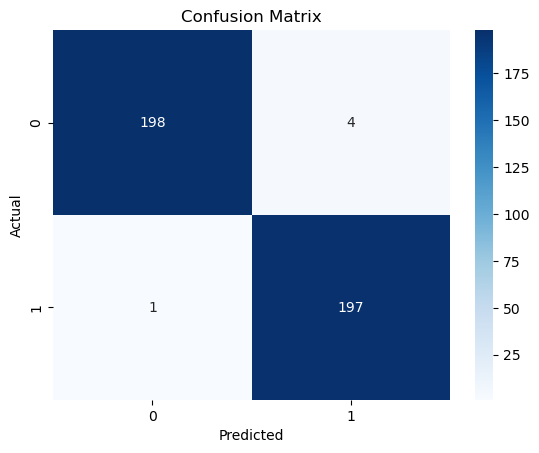

In [27]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
report = classification_report(
    y_test,
    predictions,
    output_dict=True
)

pd.DataFrame(report).transpose()

,precision,recall,f1-score,support
0,0.994975,0.980198,0.987531,202.0000
1,0.980100,0.994949,0.987469,198.0000
accuracy,0.987500,0.987500,0.987500,0.9875
macro avg,0.987537,0.987574,0.987500,400.0000
weighted avg,0.987612,0.987500,0.987500,400.0000


In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Amount,0.43
1,Gas_Fee_USD,0.32
2,Daily_Revenue_USD,0.25


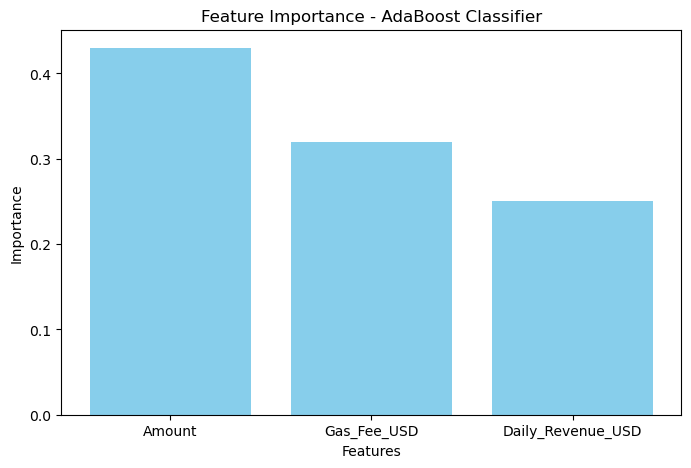

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"],
    color="skyblue"
)

plt.title("Feature Importance - AdaBoost Classifier")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

## INTERPRETATION
The AdaBoost Classifier model was used to classify transactions into Low Sales (0) and High Sales (1) using the predictor variables (Amount, Gas_Fee_USD, and Daily_Revenue_USD). The model's performance was evaluated using Accuracy, Confusion Matrix, and Classification Report. A higher accuracy indicates better classification performance, while the confusion matrix summarizes the number of correct and incorrect predictions. The classification report provides Precision, Recall, F1-Score, and Support for each class. AdaBoost improves classification accuracy by combining multiple weak decision tree models, where each new model focuses on correcting the mistakes made by previous models. The Feature Importance values identify which variables contribute most to the classification process.